In [1]:


import jax
jax.config.update("jax_enable_x64", True)
import numpy as np
import jax.numpy as jnp

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.grid'] = True
mpl.rcParams['axes.xmargin'] = 0
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['legend.frameon'] = False
mpl.rcParams['savefig.bbox'] = 'tight'

import jaxsp as jsp

from scipy import constants as const

import matplotlib.animation as animation
from IPython.display import HTML


import Stellar_sim_funcs as SSF
import importlib
importlib.reload(SSF)


from scipy.interpolate import interp1d

from collections import defaultdict

from jaxsp.constants import h, om, hbar, Msun, GN, c, m22

from collections import defaultdict

from scipy.interpolate import RegularGridInterpolator



In [2]:
m22 = 1
u = jsp.set_schroedinger_units(m22)

G = GN.value * (u.from_cm**3) / (u.from_g * u.from_s**2)

In [3]:
rho = jax.vmap(jsp.rho, in_axes=(0,None))

# rho is a function we can input array r and parameter values to get the density

In [4]:
cNFWtides_params = jnp.array([
    357964808.148399 * u.from_Msun, 
    25.690207, 
    0.407461, 
    0.012670 * u.from_Kpc, 
    1.857991 * u.from_Kpc, 
    3.729259
])
density_params = jsp.init_core_NFW_tides_params_from_sample(cNFWtides_params)
r99 = jsp.enclosing_radius(0.99, density_params) # radius that encloses 99% of mass
print(r99, "kpc")
density_params

20.743367613524313 kpc


core_NFW_tides_params:
	name=236146193804778771,
	M200=1118.7951678146808,
	c=25.690207,
	n=0.407461,
	rc=0.0005960840778498662,
	rt=0.0874126954923718,
	delta=3.729259,
    Derived:
	rs=0.026822448297135815,
	g=0.4307070628318999,
	rho0=1987135.4034031027,

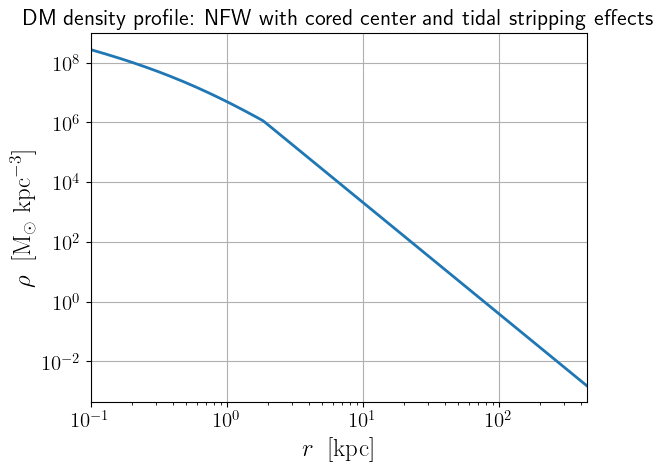

In [5]:
fig, ax = plt.subplots()
ax.xaxis.set_tick_params(labelsize=15)
ax.yaxis.set_tick_params(labelsize=15)
ax.set_xscale("log")
ax.set_yscale("log")
r = jnp.logspace(jnp.log10(100 * u.from_pc), jnp.log10(r99), 200)
ax.plot(r * u.to_Kpc, rho(r, density_params) * u.to_Msun/u.to_Kpc**3)
ax.set_ylabel(r"$\rho \;\;\mathrm{[M_\odot\;kpc^{-3}]}$", fontsize = 18)
ax.set_xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 18)
ax.set_title('DM density profile: NFW with cored center and tidal stripping effects', fontsize = 16)
plt.show()


In [6]:
potential = jax.vmap(jsp.potential, in_axes=(0,None))

In [7]:
rmin = .1 * u.from_pc
rmax = jsp.enclosing_radius(0.999, density_params)
N = 512
potential_params = jsp.init_potential_params(density_params, rmin, rmax, N) 
potential_params

potential_params:
	name=354410778964585829,
	density_params=236146193804778771,
	N=512,
	rmin=4.704688854379371e-06,
	rmax=488.53262239439164,

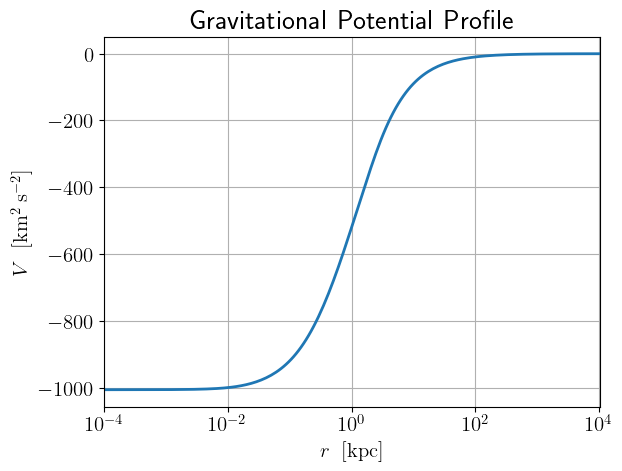

In [8]:
fig, ax = plt.subplots()
ax.set_xscale("log")
ax.xaxis.set_tick_params(labelsize=15)
ax.yaxis.set_tick_params(labelsize=15)
r = jnp.logspace(jnp.log10(rmin), jnp.log10(rmax), 200)
ax.plot(r * u.to_Kpc, potential(r, potential_params) * u.to_kms**2)
ax.set_ylabel(r"$V \;\;\mathrm{[km^2 \;s^{-2}]}$", fontsize = 15)
ax.set_xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 15)

ax.set_title('Gravitational Potential Profile', fontsize = 20)
plt.show()

In [9]:
eval_library = jax.vmap(jax.vmap(jsp.eval_radial_eigenmode, in_axes=(None, 0)), in_axes=(0,None))

In [10]:
rmin = .1 * u.from_pc
rmax = jsp.enclosing_radius(0.99, density_params)
print(rmax * u.to_Kpc)
N = 1024
a = 1
b = 10
eigenstate_lib = jsp.init_eigenstate_library(potential_params, rmin, rmax, a, b, N)
eigenstate_lib
n = eigenstate_lib.radial_eigenmode_params.n 
l = eigenstate_lib.radial_eigenmode_params.l
print(max(l))
# print(len(n))

440.90838428593
23


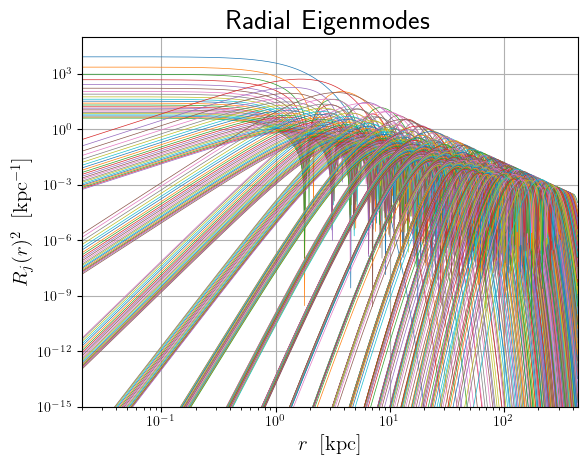

In [11]:
fig, ax = plt.subplots()
ax.set_xscale("log")
ax.set_yscale("log")
r = jnp.logspace(jnp.log10(20 * u.from_pc), jnp.log10(rmax), 1000)
R_j_r = eval_library(r, eigenstate_lib.radial_eigenmode_params)
ax.set_title('Radial Eigenmodes', fontsize = 20)
ax.set_xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 15)
ax.set_ylabel(r"$R_{j}(r)^2 \;\;\mathrm{[kpc^{-1}]}$", fontsize = 15)
ax.plot(r * u.to_Kpc, R_j_r**2, lw=0.5)
ax.set_ylim([1e-15, 1e5])
plt.show()

In [12]:
rho_psi = jax.vmap(jsp.rho_psi, in_axes=(0,None,None))

In [13]:
tol = 1e-7
rmin = 20 * u.from_pc
rmax = jsp.enclosing_radius(0.99, density_params)
wavefunction_params = jsp.init_wavefunction_params(eigenstate_lib, density_params, rmin, rmax, tol)
wavefunction_params

wavefunction_params:
	name=321443324063497960,
	eigenstate_library=720428951175803208,
	density_params=236146193804778771,
	aj_2=[3.720980066807119e-29, 0.6378987955514653],
	total_mass=716.415885628137,
	r_min=0.000940937770875874,
	r_max=20.743367613524313,
	distance=0.03034410943743295,

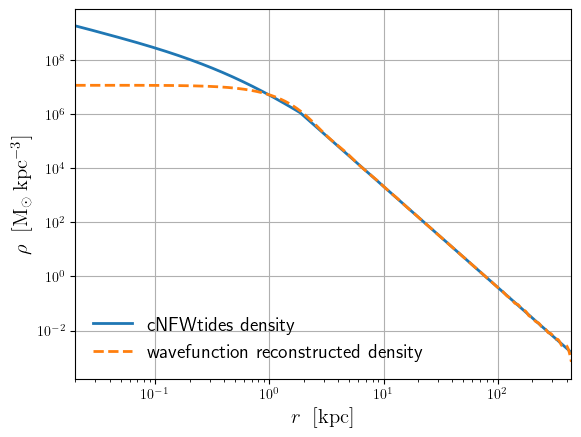

In [14]:
fig, ax = plt.subplots()
ax.set_xscale("log")
ax.set_yscale("log")

r = jnp.logspace(jnp.log10(rmin), jnp.log10(rmax), 1000)
ax.plot(r * u.to_Kpc, rho(r, density_params) * u.to_Msun / u.to_Kpc**3, label='cNFWtides density')
ax.plot(r * u.to_Kpc, rho_psi(r, wavefunction_params, eigenstate_lib) * u.to_Msun / u.to_Kpc**3, label='wavefunction reconstructed density', ls='--')
ax.set_ylabel(r"$\rho \;\;\mathrm{[M_\odot\;kpc^{-3}]}$", fontsize = 15)
ax.set_xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 15)
plt.legend(fontsize = 14)
plt.show()

# With Time Evolution

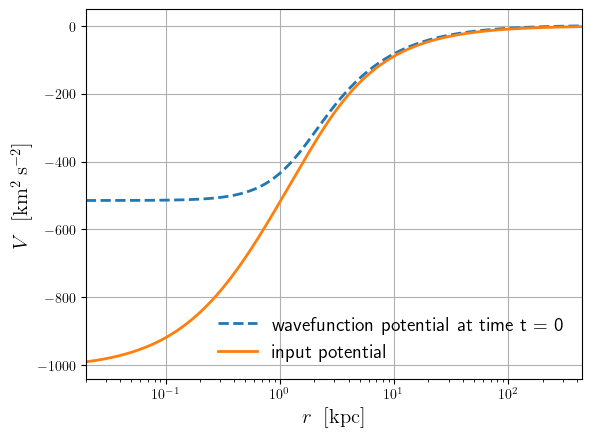

3132.937568921591


In [15]:
r = np.logspace(np.log10(rmin), np.log10(rmax), 1000)

rho_psi_vals = rho_psi(r, wavefunction_params, eigenstate_lib)

Phi_psi = SSF.Obtain_pot(rmin, rmax, rho_psi_vals, r)

fig, ax = plt.subplots()
ax.set_xscale("log")
ax.plot(r * u.to_Kpc, Phi_psi * u.to_kms**2, label='wavefunction potential at time t = 0', lw=2, ls='--')
ax.plot(r * u.to_Kpc, potential(r, potential_params) * u.to_kms**2, label='input potential', lw=2)
ax.set_ylabel(r"$V \;\;\mathrm{[km^2 \;s^{-2}]}$", fontsize = 15)
ax.set_xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 15)
plt.legend(fontsize = 14)
plt.show()

m_dm = 1 * 10**(-22) * 1.6 * 10**(-19) / (3 * 10**(8))**2  # mass of dark matter particle in units of 10^-22 eV

h_bar = hbar.value * 1e-7

dt_De_B = h_bar / (m_dm * 6000) * u.from_s # in seconds

print(dt_De_B * u.to_Gyr)

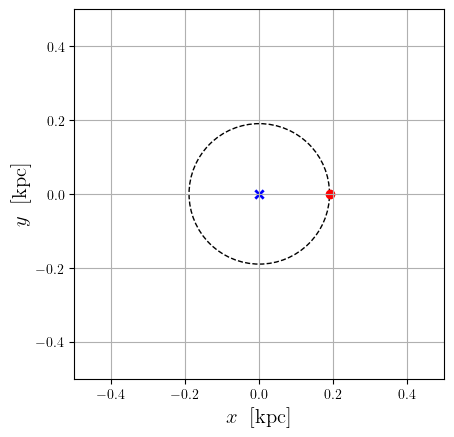

In [16]:
r_orbit = 0.19 * u.from_Kpc

init_pos = np.array([r_orbit, 0, 0]) #Starting as position (r_vir, 0, 0) = (x, y, z)

orbit = plt.Circle((0, 0), r_orbit * u.to_Kpc, color='black', fill=False, linestyle='--', label='Star Orbit')
fig, ax = plt.subplots() 

ax.add_patch(orbit)
ax.set_xlim(-0.5 , 0.5)
ax.set_ylim(-0.5 , 0.5)

ax.set_aspect('equal', adjustable='box')

plt.scatter(r_orbit * u.to_Kpc, 0, color='red', label='Star Initial Position')
plt.scatter(0, 0, color='blue', label='Halo Center', marker='x')

ax.set_xlabel(r"$x \;\;\mathrm{[kpc]}$", fontsize = 15)
ax.set_ylabel(r"$y \;\;\mathrm{[kpc]}$", fontsize = 15)
plt.show()


(1000, 290)


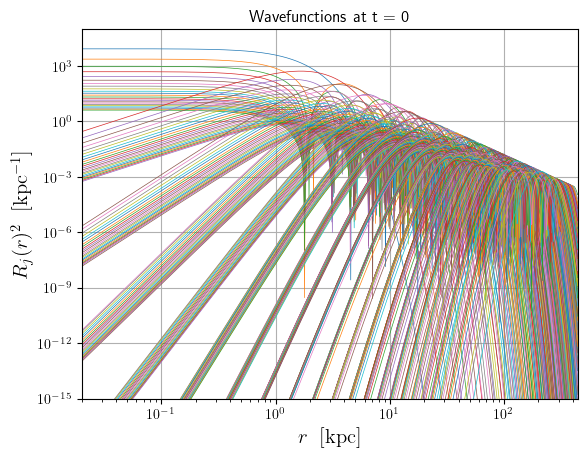

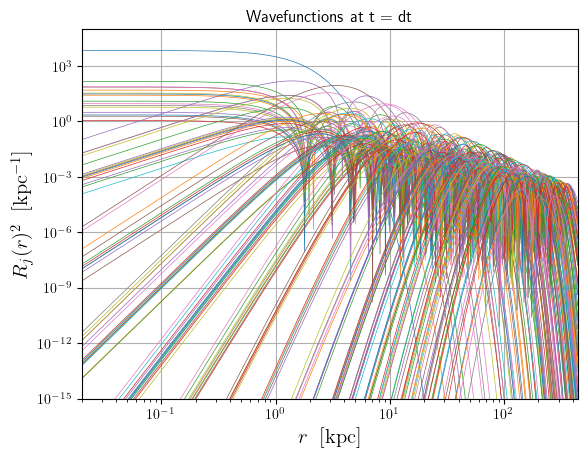

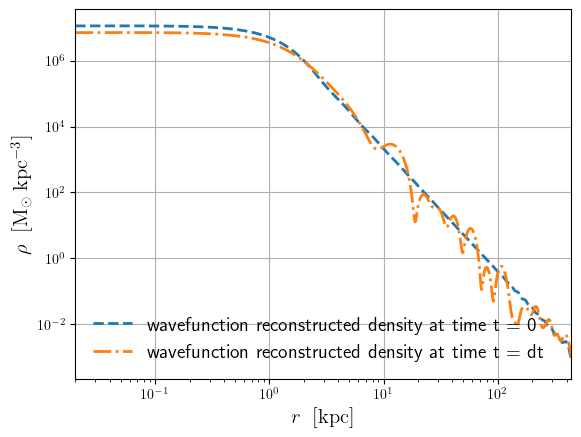

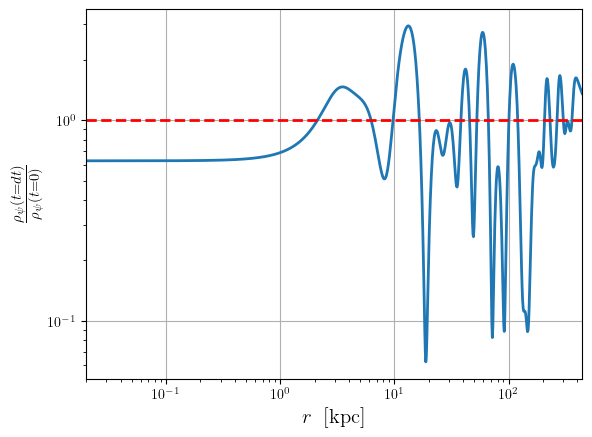

In [17]:
importlib.reload(SSF)


total_evolve_time = 5 * u.from_Gyr
num_steps = 10000
dt = total_evolve_time / num_steps

rho_rtp, rho_psi_time_stepped, radial_eigen_functions, radial_eigen_function_time_stepped, theta, phi, dtheta, dphi, Y_lms = SSF.Calculating_rho_from_psi_3d(r, eigenstate_lib, wavefunction_params, dt, eval_library)

plt.plot(r * u.to_Kpc, radial_eigen_functions**2, lw=0.5)
plt.xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize=15)
plt.ylabel(r"$R_{j}(r)^2 \;\;\mathrm{[kpc^{-1}]}$", fontsize=15)
plt.title('Wavefunctions at t = 0')
plt.xscale("log")
plt.yscale("log")
plt.ylim([1e-15, 1e5])
plt.xlim([rmin * u.to_Kpc, rmax * u.to_Kpc])
plt.show()

plt.plot(r * u.to_Kpc, radial_eigen_function_time_stepped**2, lw=0.5)
plt.title('Wavefunctions at t = dt')
plt.xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize=15)
plt.ylabel(r"$R_{j}(r)^2 \;\;\mathrm{[kpc^{-1}]}$", fontsize=15)
plt.xscale("log")
plt.yscale("log")
plt.ylim([1e-15, 1e5])
plt.show()


fig, ax = plt.subplots()
ax.set_xscale("log")
ax.set_yscale("log")

rho0 = rho_psi(r, wavefunction_params, eigenstate_lib)

ax.plot(r * u.to_Kpc,rho0 * u.to_Msun / u.to_Kpc**3,label='wavefunction reconstructed density at time t = 0',ls='--')
ax.plot(r * u.to_Kpc,rho_psi_time_stepped * u.to_Msun / u.to_Kpc**3,label='wavefunction reconstructed density at time t = dt',ls='-.')
ax.set_ylabel(r"$\rho \;\;\mathrm{[M_\odot\;kpc^{-3}]}$", fontsize=15)
ax.set_xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize=15)
plt.legend(fontsize=14)
plt.show()

fraction = rho_psi_time_stepped / rho0
plt.plot(r * u.to_Kpc, fraction)
plt.xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize=15)
plt.ylabel(r"$\frac{\rho_{\psi}(t=dt)}{\rho_{\psi}(t=0)}$", fontsize=15)
plt.axhline(1, color='red', ls='--')
plt.xscale("log")
plt.yscale("log")
plt.show()




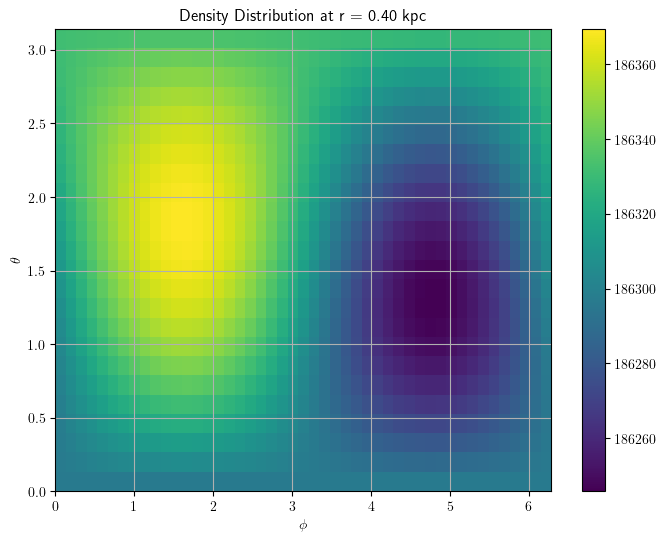

In [18]:
plt.figure(figsize=(8, 6))
i = 300
plt.imshow(rho_rtp[i,:,:], extent=(0, 2 * np.pi, 0, np.pi), aspect='auto')
plt.colorbar()
plt.xlabel(r'$\phi$')
plt.ylabel(r'$\theta$')
plt.title('Density Distribution at r = %.2f kpc' % (r[i] * u.to_Kpc))
plt.show()




In [19]:

importlib.reload(SSF)

lm_pairs = SSF.precompute_lm_pairs(int(l.max()) + 1)
G = GN.value * (u.from_cm**3) / (u.from_g * u.from_s**2)


Phi_rtp, Phi_r_dt = SSF.Calculating_Phi_from_rho_in_3d_optimized(l, rho_rtp, r, dtheta, dphi, theta, phi, lm_pairs, G)


Phi_rtp, r_vals = SSF.Calculating_Phi_from_rho_in_3d_optimized_at_r_orbit(l, rho_rtp, r, r_orbit, lm_pairs, G)

Phi_rtp = Phi_rtp.real



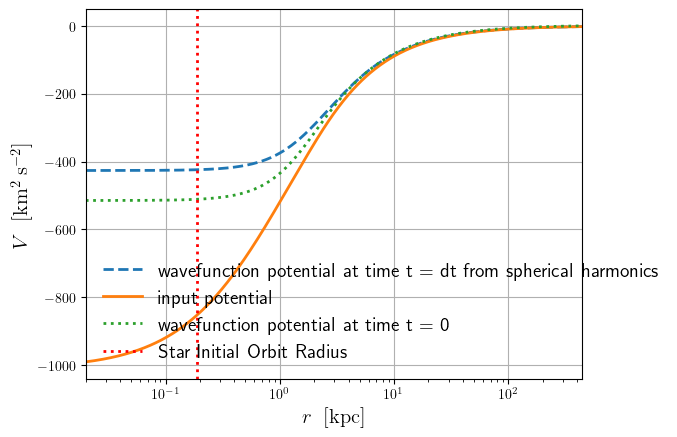

In [20]:

fig, ax = plt.subplots()
ax.set_xscale("log")
ax.plot(r * u.to_Kpc, Phi_r_dt * u.to_kms**2, label='wavefunction potential at time t = dt from spherical harmonics', lw=2, ls='--')
ax.plot(r * u.to_Kpc, potential(r, potential_params) * u.to_kms**2, label='input potential', lw=2)
ax.plot(r * u.to_Kpc, Phi_psi * u.to_kms**2, label='wavefunction potential at time t = 0', lw=2, ls=':')
ax.axvline(r_orbit * u.to_Kpc, color='red', ls=':', label='Star Initial Orbit Radius')
ax.set_ylabel(r"$V \;\;\mathrm{[km^2 \;s^{-2}]}$", fontsize = 15)
ax.set_xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 15)
plt.legend(fontsize = 14)
plt.show()




# Create new u.to_kpc as need to only multiply r term by it

In [21]:
to_kpc = jnp.array([u.to_Kpc, 1, 1])

## $\vec{a} = -\vec{\nabla} V$
## $\vec{a} = -(\frac{dV}{dr}\vec{\hat{r}} + \frac{1}{r}\frac{dV}{d\theta}\vec{\hat{\theta}} + \frac{1}{r\sin{\theta}}\frac{dV}{d\phi}\vec{\hat{\phi}})$

In [22]:
print(r_vals * u.to_Kpc)

import importlib
importlib.reload(SSF)

init_pos_sph = SSF.Cartesian_to_sph(init_pos[0], init_pos[1], init_pos[2])

acc_vec = SSF.Acc_from_pot_3d(Phi_rtp, r_vals, theta, phi) # (3, 3, n_theta, n_phi) = (dim, Nr, n_theta, n_phi)

# Reshape to (r, theta, phi, 3) for a single interpolator
data_transposed = np.moveaxis(acc_vec, 0, -1)  # shape (3, 24, 47, 3)

interp = RegularGridInterpolator(
    (r_vals, theta, phi),
    data_transposed,
    method='linear'
)

print("Star spherical position: ", init_pos_sph * to_kpc)
result = interp(list(init_pos_sph))

print(result[0])

[0.17209894 0.17383045 0.17557939 0.17734592 0.17913022 0.18093247
 0.18275286 0.18459157 0.18644877 0.18832466 0.19021942 0.19213325
 0.19406633 0.19601886 0.19799103 0.19998305 0.20199511 0.20402741
 0.20608016 0.20815356 0.21024783]
Star spherical position:  [0.19       1.57079633 0.        ]
[-6.31998226e+02 -6.13205558e-01  1.88361060e+00]


# Time dependent simulation run

## Leapfrog Integration

In [23]:
# importlib.reload(SSF)

# total_evolve_time = 5 * u.from_Gyr
# num_steps = 500
# dt = total_evolve_time / num_steps
# num_steps = 500

# r = np.logspace(np.log10(rmin), np.log10(rmax), 1000)

# r_orbit = 0.19 * u.from_Kpc

# init_pos = np.array([r_orbit, 0, 0]) #Starting as position (r_vir, 0, 0) = (x, y, z)

# print("Star initial position (kpc): ", init_pos * u.to_Kpc)

# eigen_energies = eigenstate_lib.radial_eigenmode_params.E  # shape (Nj,)
# total_mass = wavefunction_params.total_mass
# R_j_r = eval_library(r, eigenstate_lib.radial_eigenmode_params)
# l = eigenstate_lib.radial_eigenmode_params.l

# aj_2 = wavefunction_params.aj_2        # shape (Nj,)
# rand_phase = jax.random.uniform(jax.random.PRNGKey(0), shape=aj_2.shape, minval=0.0, maxval=2 * jnp.pi,)
# aj = np.sqrt(aj_2) * np.exp(1j * rand_phase)  # shape (Nj,)


# stellar_v_disp, total_avg_r, r_values, velocities = SSF.Simulate_time_dep_3d(r_orbit, init_pos, dt, num_steps, r, eigen_energies, l, R_j_r, aj, total_mass, Phi_psi, Y_lms)



In [24]:
# fig, ax = plt.subplots()


# ax.plot(np.arange(num_steps) * dt * u.to_Gyr, jnp.array(total_avg_r) * u.to_Kpc, label='Average Radial Distance from Halo Center', ls='--')
# #ax.plot(np.arange(num_steps) * dt * u.to_Gyr, jnp.array(r_values) * u.to_Kpc, label='Star Radial Distance from Halo Center', ls='-')
# ax.axhline(r_orbit * u.to_Kpc, color='red', ls=':', label='Initial Orbit Radius')
# ax.set_ylabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 15)
# ax.set_xlabel(r"Gyr", fontsize = 15)
# plt.legend(fontsize = 14)
# plt.show()

# fig, ax = plt.subplots()

# stellar_v_disp = jnp.array(stellar_v_disp)


# ax.plot(np.arange(num_steps) * dt * u.to_Gyr, stellar_v_disp * u.to_kms, label='Stellar Velocity Dispersion')
# plt.yscale('log')
# ax.set_ylabel(r"$\sigma_v \;\;\mathrm{[km/s]}$", fontsize = 15)
# ax.set_xlabel(r"Gyr", fontsize = 15)
# plt.legend(fontsize = 14)
# plt.show()

## Hanno Reins

In [ ]:
importlib.reload(SSF)

total_evolve_time = 5 * u.from_Gyr
num_steps = 1000
dt = total_evolve_time / num_steps
num_steps = 1000

r = np.logspace(np.log10(rmin), np.log10(rmax), 1000)

r_orbit = 0.19 * u.from_Kpc

init_pos = np.array([r_orbit, 0, 0]) #Starting as position (r_vir, 0, 0) = (x, y, z)

print("Star initial position (kpc): ", init_pos * u.to_Kpc)

eigen_energies = eigenstate_lib.radial_eigenmode_params.E  # shape (Nj,)
total_mass = wavefunction_params.total_mass
R_j_r = eval_library(r, eigenstate_lib.radial_eigenmode_params)
l = eigenstate_lib.radial_eigenmode_params.l

aj_2 = wavefunction_params.aj_2        # shape (Nj,)
rand_phase = jax.random.uniform(jax.random.PRNGKey(0), shape=aj_2.shape, minval=0.0, maxval=2 * jnp.pi,)
aj = np.sqrt(aj_2) * np.exp(1j * rand_phase)  # shape (Nj,)


stellar_v_disp, total_avg_r, r_values, velocities = SSF.Simulate_time_dep_3d_Hanno_Reins(r_orbit, init_pos, dt, num_steps, r, eigen_energies, l, R_j_r, aj, total_mass, Phi_psi, Y_lms, print_every = 10)



Star initial position (kpc):  [0.19 0.   0.  ]
Initialization time (s):  0.01107335090637207
Star position (r, theta, phi) in kpc:  [0.19000067 1.57079633 0.072851  ]
Time for wavefunction update (s):  0.04740190505981445
Time taken for forward SHT (s):  0.1263570785522461
Time taken for integration at r_orbit (s):  0.1551189422607422
Time taken for inverse SHT at r_orbit (s):  0.0034050941467285156
(3, 24, 47) (3,)
Time for acceleration field calculation (s):  0.0044040679931640625
Time for updating particle position and interpolating acc (s):  0.044432878494262695
Star position (r, theta, phi) in kpc:  [0.19008253 1.57080398 0.14581192]
Time for wavefunction update (s):  0.04459810256958008
Time taken for forward SHT (s):  0.1159212589263916
Time taken for integration at r_orbit (s):  0.03490400314331055
Time taken for inverse SHT at r_orbit (s):  0.001977682113647461
(3, 24, 47) (3,)
Time for acceleration field calculation (s):  0.0029249191284179688
Time for updating particle posit

## Showing velocity and speed distributions by the end of the simulation
## Showing the growth of the average radial position of the particle and its velocity dispersion

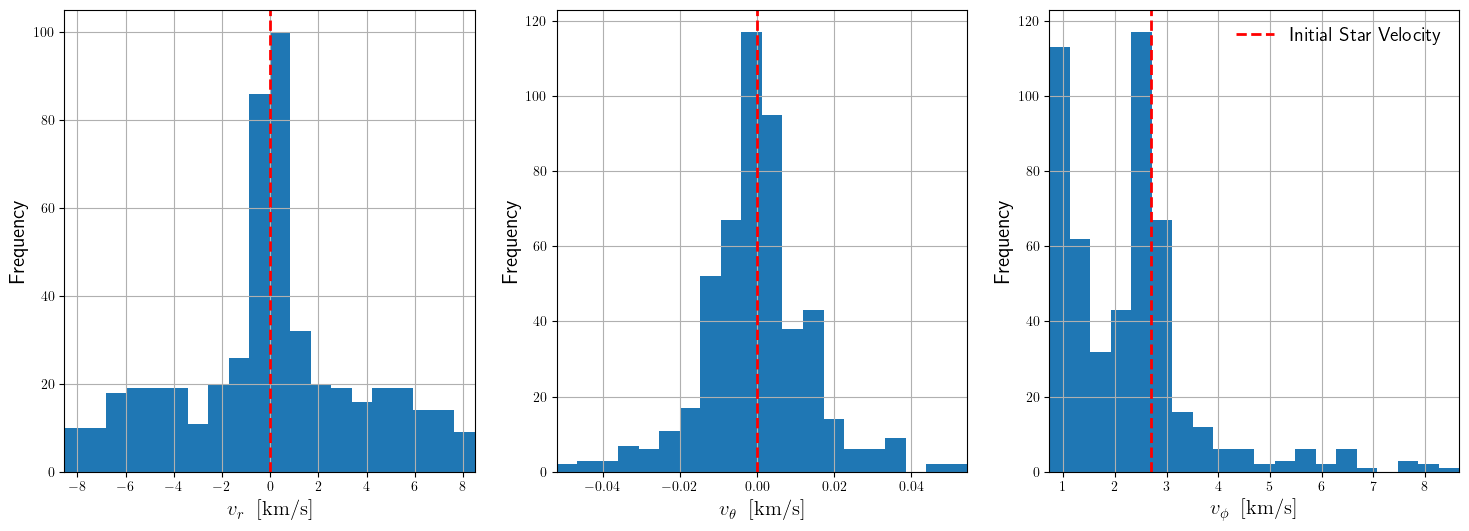

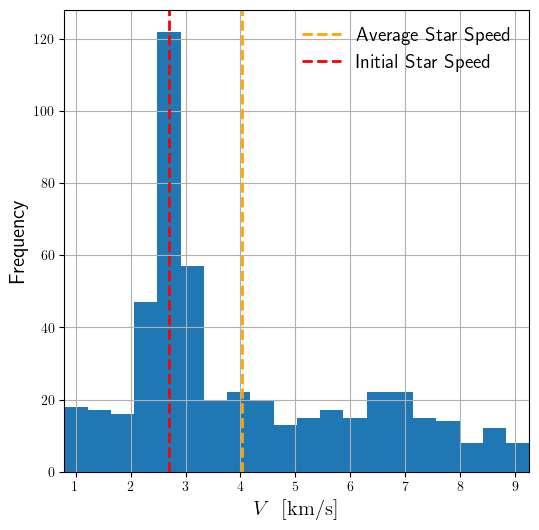

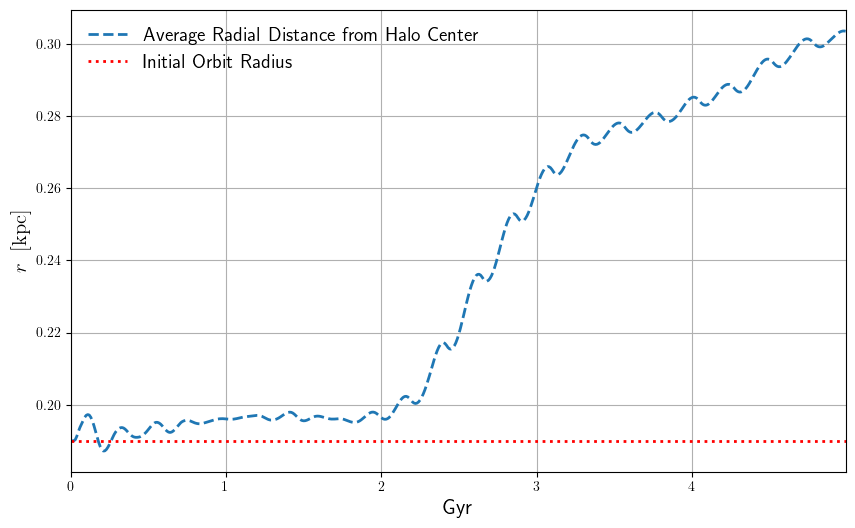

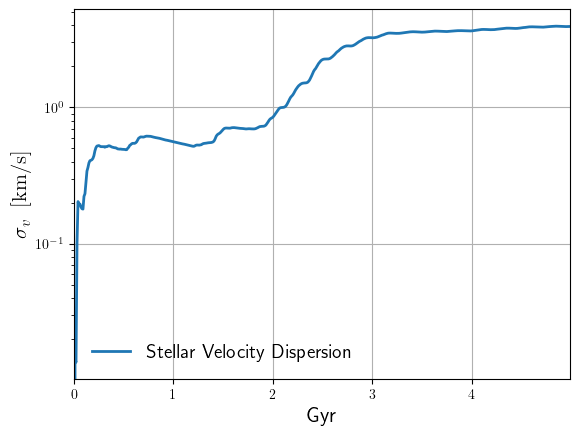

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(18,6))

ax[0].hist(velocities[:,0] * u.to_kms, bins=20)
ax[0].axvline(0, color='red', ls='--', label='Initial Star Velocity')
ax[0].set_xlabel(r"$v_r \;\;\mathrm{[km/s]}$", fontsize = 15)
ax[0].set_ylabel("Frequency", fontsize = 15)

ax[1].hist(velocities[:,1] * u.to_kms, bins=20)
ax[1].axvline(0, color='red', ls='--', label='Initial Star Velocity')
ax[1].set_xlabel(r"$v_\theta \;\;\mathrm{[km/s]}$", fontsize = 15)
ax[1].set_ylabel("Frequency", fontsize = 15)

acc_mag = SSF.Find_acc_mag_from_Phi(r, Phi_psi, r_orbit)

init_vel = np.sqrt(acc_mag * r_orbit) * np.array([0, 1, 0])

init_vel_sph = SSF.Cartesian_to_sph_vel(init_pos[0], init_pos[1], init_pos[2], init_vel[0], init_vel[1], init_vel[2])

ax[2].hist(velocities[:,2] * u.to_kms, bins=20)
ax[2].set_xlabel(r"$v_\phi \;\;\mathrm{[km/s]}$", fontsize = 15)
ax[2].axvline(init_vel_sph[2] * u.to_kms, color='red', ls='--', label='Initial Star Velocity')
ax[2].set_ylabel("Frequency", fontsize = 15)
ax[2].legend(fontsize = 14)
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))

speeds = jnp.sqrt(velocities[:,0]**2 + velocities[:,1]**2 + velocities[:,2]**2)
avg_speed = jnp.mean(speeds)
ax.hist(speeds * u.to_kms, bins=20)
ax.axvline(avg_speed * u.to_kms, color='orange', ls='--', label='Average Star Speed')
ax.axvline(np.sqrt(init_vel_sph[0]**2 + init_vel_sph[1]**2 + init_vel_sph[2]**2) * u.to_kms, color='red', ls='--', label='Initial Star Speed')
ax.set_xlabel(r"$V \;\;\mathrm{[km/s]}$", fontsize = 15)
ax.set_ylabel("Frequency", fontsize = 15)
plt.legend(fontsize = 14)
plt.show()


fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(np.arange(num_steps) * dt * u.to_Gyr, jnp.array(total_avg_r) * u.to_Kpc, label='Average Radial Distance from Halo Center', ls='--')
#ax.plot(np.arange(num_steps) * dt * u.to_Gyr, jnp.array(r_values) * u.to_Kpc, label='Star Radial Distance from Halo Center', ls='-')
ax.axhline(r_orbit * u.to_Kpc, color='red', ls=':', label='Initial Orbit Radius')
ax.set_ylabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 15)
ax.set_xlabel(r"Gyr", fontsize = 15)
plt.legend(fontsize = 14)
plt.show()

fig, ax = plt.subplots()

stellar_v_disp = jnp.array(stellar_v_disp)


ax.plot(np.arange(num_steps) * dt * u.to_Gyr, stellar_v_disp * u.to_kms, label='Stellar Velocity Dispersion')
plt.yscale('log')
ax.set_ylabel(r"$\sigma_v \;\;\mathrm{[km/s]}$", fontsize = 15)
ax.set_xlabel(r"Gyr", fontsize = 15)
plt.legend(fontsize = 14)
plt.show()

# Convergence testing

In [ ]:
importlib.reload(SSF)

total_evolve_time = 5 * u.from_Gyr
num_steps = np.logspace(1, np.log10(3000), 6).astype(int)
print(num_steps)

r = np.logspace(np.log10(rmin), np.log10(rmax), 1000)

r_orbit = 0.19 * u.from_Kpc

init_pos = np.array([r_orbit, 0, 0]) #Starting as position (r_vir, 0, 0) = (x, y, z)

print("Star initial position (kpc): ", init_pos * u.to_Kpc)

eigen_energies = eigenstate_lib.radial_eigenmode_params.E  # shape (Nj,)
total_mass = wavefunction_params.total_mass
R_j_r = eval_library(r, eigenstate_lib.radial_eigenmode_params)
l = eigenstate_lib.radial_eigenmode_params.l

aj_2 = wavefunction_params.aj_2        # shape (Nj,)
rand_phase = jax.random.uniform(jax.random.PRNGKey(0), shape=aj_2.shape, minval=0.0, maxval=2 * jnp.pi,)
aj = np.sqrt(aj_2) * np.exp(1j * rand_phase)  # shape (Nj,)


total_avg_r_conv = []
stellar_v_disp_conv = []

for n_steps in num_steps:
    dt = total_evolve_time / n_steps
    print("Number of steps: ", n_steps)
    stellar_v_disp, total_avg_r, r_values, velocities = SSF.Simulate_time_dep_3d_Hanno_Reins(r_orbit, init_pos, dt, n_steps, r, eigen_energies, l, R_j_r, aj, total_mass, Phi_psi, Y_lms, print_every = 10)
    total_avg_r_conv.append(total_avg_r)
    stellar_v_disp_conv.append(stellar_v_disp)


[  10   31   97  306  958 3000]
Star initial position (kpc):  [0.19 0.   0.  ]
Number of steps:  10
Number of steps:  31
Step 10/31
Step 20/31
Number of steps:  97
Step 10/97
Step 20/97
Step 30/97
Step 40/97
Step 50/97
Step 60/97
Step 70/97
Step 80/97
Step 90/97
Number of steps:  306
Step 10/306
Step 20/306
Step 30/306
Step 40/306
Step 50/306
Step 60/306
Step 70/306
Step 80/306
Step 90/306
Step 100/306
Step 110/306
Step 120/306
Step 130/306
Step 140/306
Step 150/306
Step 160/306
Step 170/306
Step 180/306
Step 190/306
Step 200/306
Step 210/306
Step 220/306
Step 230/306
Step 240/306
Step 250/306
Step 260/306
Step 270/306
Step 280/306
Step 290/306
Step 300/306
Number of steps:  958
Step 10/958
Step 20/958
Step 30/958
Step 40/958
Step 50/958
Step 60/958
Step 70/958
Step 80/958
Step 90/958
Step 100/958
Step 110/958
Step 120/958
Step 130/958
Step 140/958
Step 150/958
Step 160/958
Step 170/958
Step 180/958
Step 190/958
Step 200/958
Step 210/958
Step 220/958
Step 230/958
Step 240/958
Step 250/

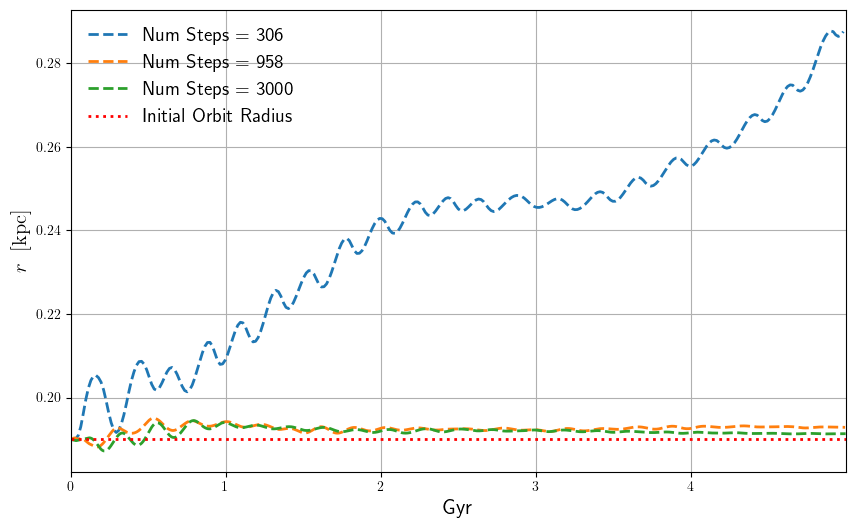

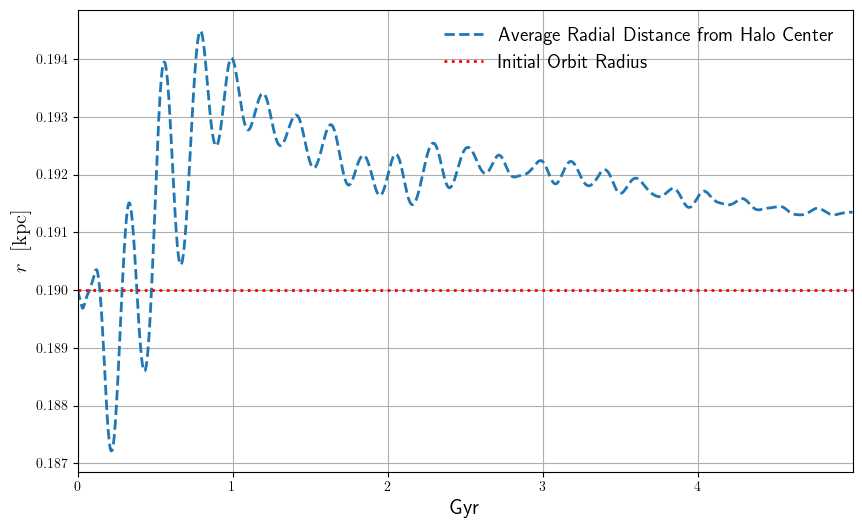

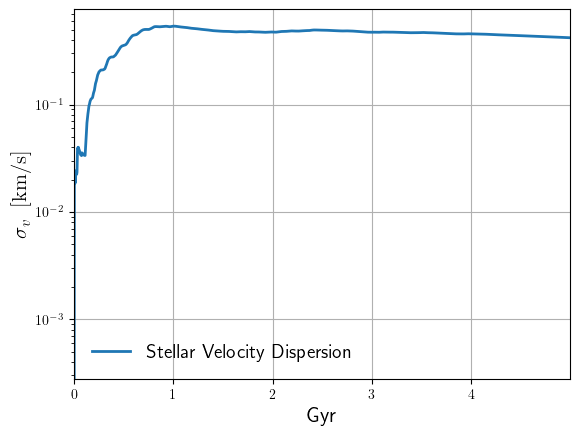

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
for i in range(3, len(num_steps)):
    n_steps = num_steps[i]
    dt = total_evolve_time / n_steps
    total_avg_r = total_avg_r_conv[i]
    ax.plot(np.arange(n_steps) * dt * u.to_Gyr, jnp.array(total_avg_r) * u.to_Kpc, ls='--', label='Num Steps = %d' % n_steps)
ax.axhline(r_orbit * u.to_Kpc, color='red', ls=':', label='Initial Orbit Radius')
ax.set_ylabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 15)
ax.set_xlabel(r"Gyr", fontsize = 15)
plt.legend(fontsize = 14)
plt.show()


fig, ax = plt.subplots(figsize=(10, 6))


ax.plot(np.arange(num_steps[-1]) * dt * u.to_Gyr, jnp.array(total_avg_r) * u.to_Kpc, label='Average Radial Distance from Halo Center', ls='--')
#ax.plot(np.arange(num_steps) * dt * u.to_Gyr, jnp.array(r_values) * u.to_Kpc, label='Star Radial Distance from Halo Center', ls='-')
ax.axhline(r_orbit * u.to_Kpc, color='red', ls=':', label='Initial Orbit Radius')
ax.set_ylabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 15)
ax.set_xlabel(r"Gyr", fontsize = 15)
plt.legend(fontsize = 14)
plt.show()

fig, ax = plt.subplots()

stellar_v_disp = jnp.array(stellar_v_disp)


ax.plot(np.arange(num_steps[-1]) * dt * u.to_Gyr, stellar_v_disp * u.to_kms, label='Stellar Velocity Dispersion')
plt.yscale('log')
ax.set_ylabel(r"$\sigma_v \;\;\mathrm{[km/s]}$", fontsize = 15)
ax.set_xlabel(r"Gyr", fontsize = 15)
plt.legend(fontsize = 14)
plt.show()

Frame:  0
Acceleration vector (a_r, a_theta, a_phi) at star position:  [-1005.74949982    -0.            -0.        ]
[ 0.19001067 33.38788973  3.10508361]
Time taken for potential calculation at r_orbit (s):  2.0461413860321045
Frame:  0
Acceleration vector (a_r, a_theta, a_phi) at star position:  [-1026.89907801    -3.49149712     1.14817611]
[ 0.19006453 33.38710814  6.24249469]
Time taken for potential calculation at r_orbit (s):  2.1650149822235107
Frame:  0
Acceleration vector (a_r, a_theta, a_phi) at star position:  [-1026.8756648     -3.49340482     1.11532773]
[ 0.19020604 33.38477371  9.41132634]
Time taken for potential calculation at r_orbit (s):  1.9165751934051514
Frame:  0
Acceleration vector (a_r, a_theta, a_phi) at star position:  [-1027.08537958    -3.49484106     1.05692137]
[ 0.1905174  33.38092904 12.60750397]
Time taken for potential calculation at r_orbit (s):  2.26336932182312
Frame:  1
Acceleration vector (a_r, a_theta, a_phi) at star position:  [-1.02773170e+0

ValueError: One of the requested xi is out of bounds in dimension 2

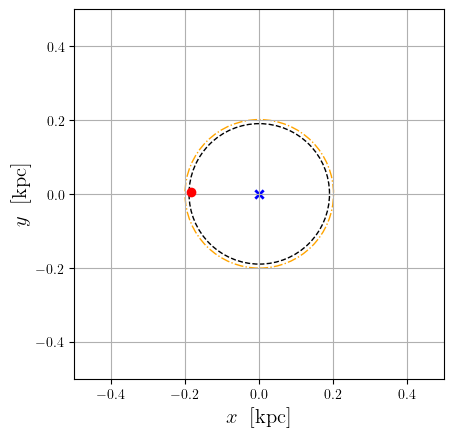

In [ ]:
importlib.reload(SSF)


total_evolve_time = 10 * u.from_Gyr
num_steps = 1000
dt = total_evolve_time / num_steps
num_steps = 300

r = jnp.logspace(jnp.log10(rmin), jnp.log10(rmax), 1000)

r_orbit = 0.19 * u.from_Kpc
init_pos = np.array([r_orbit, 0, 0]) #Starting as position (r_vir, 0, 0) = (x, y, z)

init_vel = np.sqrt(acc_mag * r_orbit) * np.array([0, 1, 0]) #Circular orbit velocity

eigen_energies = eigenstate_lib.radial_eigenmode_params.E  # shape (Nj,)
total_mass = wavefunction_params.total_mass
R_j_r = eval_library(r, eigenstate_lib.radial_eigenmode_params)
l = eigenstate_lib.radial_eigenmode_params.l

aj_2 = wavefunction_params.aj_2        # shape (Nj,)
rand_phase = jax.random.uniform(jax.random.PRNGKey(0), shape=aj_2.shape, minval=0.0, maxval=2 * jnp.pi,)
aj = np.sqrt(aj_2) * np.exp(1j * rand_phase)  # shape (Nj,)


ani = SSF.Make_animation_t_dep_3d(r_orbit, init_pos, init_vel, dt, num_steps, r, eigen_energies, l, R_j_r, aj, total_mass, Y_lms, Phi_psi)

HTML(ani.to_jshtml())